# D3: Bessel low-pass filter in ODE form - summary

Here, we summarise the 1, 2, 3, 4, and 6-pole Bessel filter ODEs.

## The 1-pole Bessel low-pass filter

\begin{align}
\dot{y}(t) = \frac{u(t) - y(t)}{\alpha}
\end{align}

where

\begin{align}
\alpha &= \frac{t_r}{\log 9} = \frac{1}{2 \pi f_c} 
\quad \rightarrow \quad
f_c = \frac{\log 9}{2 \pi t_r}
\end{align}

for **cut-off frequency** $f_c$ and **rise time** $t_r$.

Simulating with $t$ in ms, $t_r$ is in ms and $f_c$ is in kHz.

## The 2-pole Bessel low-pass filter

\begin{align}
\dot{y_1} &= \frac{3}{\alpha^2}u(t) - \frac{3}{\alpha^2}y_2 - \frac{3}{\alpha}y_1 \\
\dot{y_2} &= y_1
\end{align}

where $y_2(t)$ is the filter's output, and

\begin{align}
\alpha \approx \frac{1.3616}{2 \pi f_c} = \frac{1.3616}{\log(9)}t_r
\end{align}

Here, $t_r$ is the **first order** rise time.

## The 3-pole Bessel low-pass filter

The 3-pole filter can be broken down into a 2-pole and a 1-pole filter in series.


And with these we can break down the 3-pole low-pass Bessel filter into a first-order filter
\begin{align}
\dot{y} = \frac{u(t) - y(t)}{1 / 2.32}
\end{align}

\begin{align}
\ddot{y}(t) = 6.4594u(t) - 3.6778\dot{y}(t) - 6.4594y(t),\quad y(0)=0, \quad \dot{y}(0)=0
\end{align}

u = sin(2 * 3.14159 * t / 5) + sin(2 * 3.14159 * t * 5)
dot(y1) = (u - y1) * 2.3222
dot(y2) = 6.4594 * (y1 - y3) - 3.6778 * y2
dot(y3) = y2

## The 4-pole Bessel low-pass filter


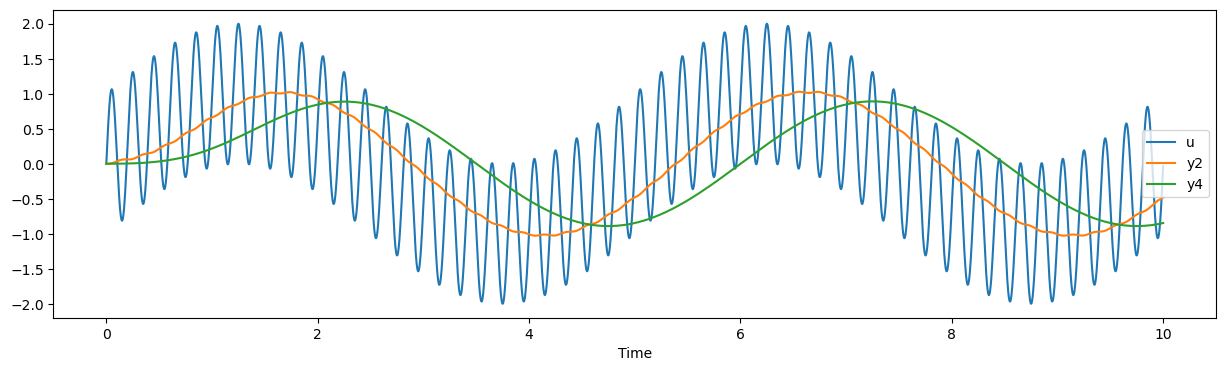

In [18]:
m = myokit.parse_model("""
[[model]]
f.y1 = 0
f.y2 = 0
f.y3 = 0
f.y4 = 0

[f]
t = 0 bind time
u = sin(2 * 3.14159 * t / 5) + sin(2 * 3.14159 * t * 5)
dot(y1) = 11.488 * (u - y2) - 4.2076 * y1
dot(y2) = y1
dot(y3) = 9.1401 * (y2 - y4) - 5.7924 * y3
dot(y4) = y3
    desc: The 4-pole filtered output
""")
s = myokit.Simulation(m)
e = s.run(10, log_interval=0.001)

fig = plt.figure(figsize=(15, 4))
ax = fig.add_subplot()
ax.set_xlabel('Time')
ax.plot(e.time(), e['f.u'], label='u')
ax.plot(e.time(), e['f.y2'], label='y2')
ax.plot(e.time(), e['f.y4'], label='y4')
ax.legend(loc='right')
plt.show()

Before working out the natural frequency and scaling, we'll just compare with the natural version returned by SciPy:

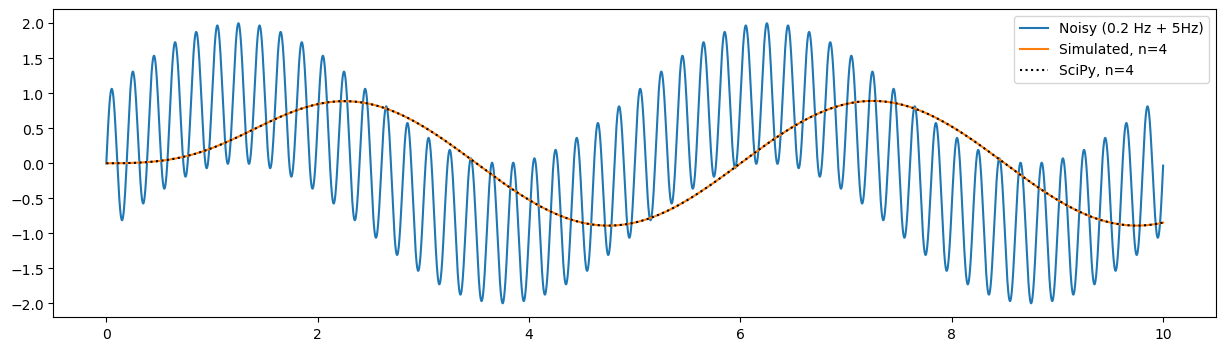

In [19]:
t, u, y = e.time(), e['f.u'], e['f.y4']

fig = plt.figure(figsize=(15, 4))
ax = fig.add_subplot()
ax.plot(t, u, label='Noisy (0.2 Hz + 5Hz)')
ax.plot(t, y, label='Simulated, n=4')
ax.plot(*low_pass_natural(t, u, n=4), 'k:', label='SciPy, n=4')
ax.legend()
plt.show()

Looks exactly right.

#### Scalable filter with even number of poles

Finally, we'll work out how to make this 4-pole filter scalable, and write the results in a way that extends to any even-numbered order low-pass Bessel filter.

To do this, we add a scaling factor $\alpha$ to every $s$
\begin{align}
H_{2m}(s) &= \prod_i^m \frac{\sigma_i^2 + \omega_i^2}{(\alpha s)^2 + 2 \sigma_i (\alpha s) + \sigma_i^2 + \omega_i^2} \\
\end{align}
to find
\begin{align}
\ddot{y_i}(t) = \frac{\sigma_i^2 + \omega_i^2}{\alpha^2}(u(t) - y(t)) - \frac{2\sigma_i}{\alpha}\dot{y}(t)
\end{align}
where
\begin{align}
\alpha = \frac{\omega_0}{2 \pi f}
\end{align}
where $\omega_0$ is the unscaled cut-off frequency in rad/sec and where $f$ is the desired cut-off frequency in Hz.

We can find $\omega_0$ using SciPy and fmin:

In [20]:
print(f'{bessel_natural_cutoff(4):.5} rad/sec')

2.114 rad/sec


Let's try it in a model:

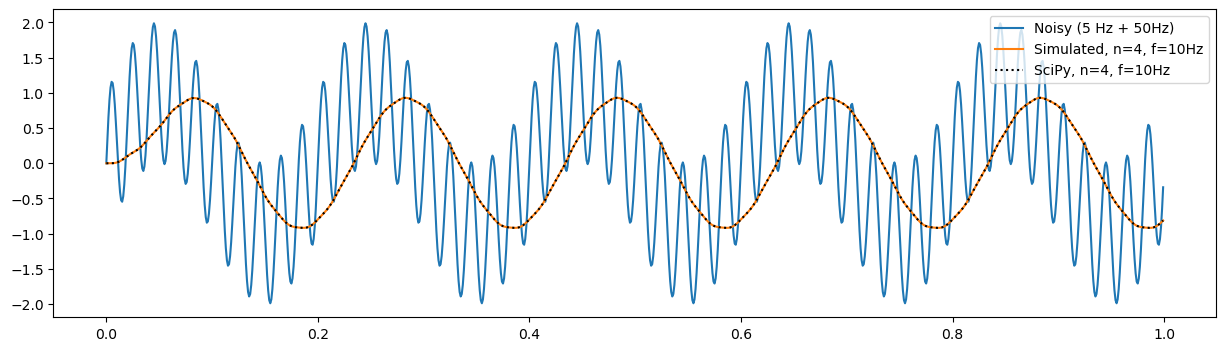

In [21]:
m = myokit.parse_model("""
[[model]]
f.y1 = 0
f.y2 = 0
f.y3 = 0
f.y4 = 0

[f]
t = 0 bind time
pi = 3.14159
u = sin(2 * pi * 5 * t) + sin(2 * pi * 50 * t)
f = 10 [Hz]
alpha = 2.114 / (2 * pi * f)
dot(y1) = 11.488 / alpha^2 * (u - y2) - 4.2076 / alpha * y1
dot(y2) = y1
dot(y3) = 9.1401 / alpha^2 * (y2 - y4) - 5.7924 / alpha * y3
dot(y4) = y3
    desc: The 4-pole filtered output
""")
s = myokit.Simulation(m)
e = s.run(1, log_interval=0.001)

t, u, y = e.time(), e['f.u'], e['f.y4']

fig = plt.figure(figsize=(15, 4))
ax = fig.add_subplot()
ax.plot(t, u, label='Noisy (5 Hz + 50Hz)')
ax.plot(t, y, label='Simulated, n=4, f=10Hz')
ax.plot(*low_pass(t, u, 10, n=4), 'k:', label='SciPy, n=4, f=10Hz')
ax.legend()
plt.show()

Looks great!

### Six pole Bessel filters

Applying the same methods for a six pole filter we obtain:

In [22]:
print(even_poles(6))

2 sigma_1 = 5.0319
(sigma_1^2 + omega_1^2) = 26.514
2 sigma_2 = 7.4714
(sigma_2^2 + omega_2^2) = 20.853
2 sigma_3 = 8.4967
(sigma_3^2 + omega_3^2) = 18.801
None


In [23]:
print(f'{bessel_natural_cutoff(6):.5} rad/sec')

2.7034 rad/sec


We can find $\omega_0$ using SciPy and fmin:

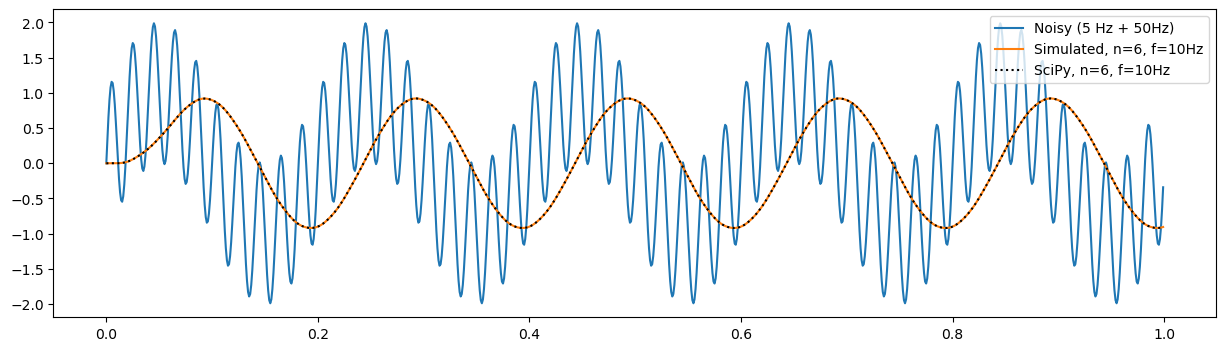

In [24]:
m = myokit.parse_model("""
[[model]]
f.y1 = 0
f.y2 = 0
f.y3 = 0
f.y4 = 0
f.y5 = 0
f.y6 = 0

[f]
t = 0 bind time
pi = 3.14159
u = sin(2 * pi * 5 * t) + sin(2 * pi * 50 * t)
f = 10 [Hz]
alpha = 2.7034 / (2 * pi * f)
dot(y1) = 26.514 / alpha^2 * (u - y2) - 5.0319 / alpha * y1
dot(y2) = y1
dot(y3) = 20.853 / alpha^2 * (y2 - y4) - 7.4714 / alpha * y3
dot(y4) = y3
dot(y5) = 18.801 / alpha^2 * (y4 - y6) - 8.4967 / alpha * y5
dot(y6) = y5
    desc: The 6-pole filtered output
""")
s = myokit.Simulation(m)
e = s.run(1, log_interval=0.001)
t, u, y = e.time(), e['f.u'], e['f.y6']

fig = plt.figure(figsize=(15, 4))
ax = fig.add_subplot()
ax.plot(t, u, label='Noisy (5 Hz + 50Hz)')
ax.plot(t, y, label='Simulated, n=6, f=10Hz')
ax.plot(*low_pass(t, u, 10, n=6), 'k:', label='SciPy, n=6, f=10Hz')
ax.legend()
plt.show()

It works!

## First-order approximations

Finally, we compare a 6-pole filter with a 1-pole approximation.

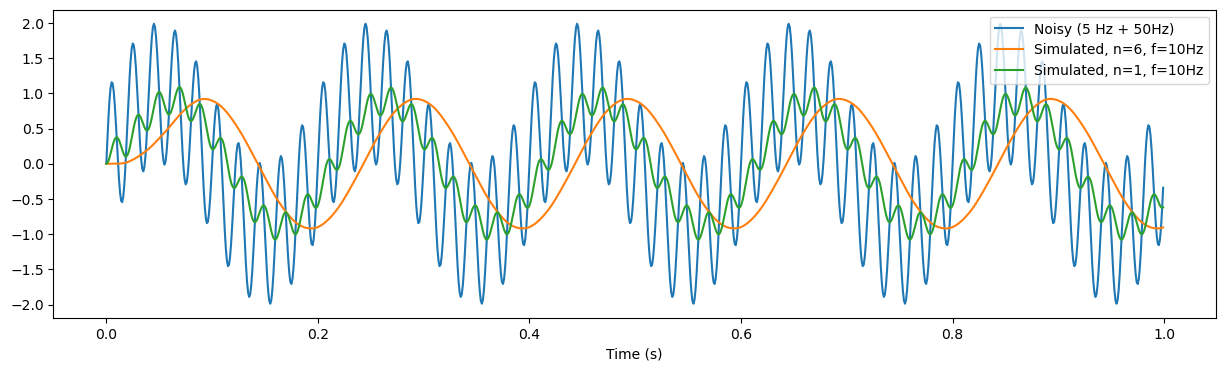

In [25]:
m = myokit.parse_model("""
[[model]]
f.y1 = 0
f.y2 = 0
f.y3 = 0
f.y4 = 0
f.y5 = 0
f.y6 = 0
f.z1 = 0

[f]
t = 0 bind time
p = 0 bind pace
pi = 3.14159
u = sin(2 * pi * 5 * t) + sin(2 * pi * 50 * t)
f = 10 [Hz]
a1 = 1 / (2 * pi * f)
a6 = 2.7034 / (2 * pi * f)
dot(y1) = 26.514 / a6^2 * (u - y2) - 5.0319 / a6 * y1
dot(y2) = y1
dot(y3) = 20.853 / a6^2 * (y2 - y4) - 7.4714 / a6 * y3
dot(y4) = y3
dot(y5) = 18.801 / a6^2 * (y4 - y6) - 8.4967 / a6 * y5
dot(y6) = y5
    desc: The 6-pole filtered output
dot(z1) = (u - z1) / a1
    desc: The 1-pole filtered output
""")
s = myokit.Simulation(m)
e = s.run(1, log_interval=0.001)
t, u, y, z = e.time(), e['f.u'], e['f.y6'], e['f.z1']

fig = plt.figure(figsize=(15, 4))
ax = fig.add_subplot()
ax.set_xlabel('Time (s)')
ax.plot(t, u, label='Noisy (5 Hz + 50Hz)')
ax.plot(t, y, label='Simulated, n=6, f=10Hz')
ax.plot(t, z, label='Simulated, n=1, f=10Hz')
ax.legend()
plt.show()

The 1-pole filter doesn't filter out the high frequencies as well, but has considerably less lag.
_However_, for patch-clamping we're much more interested in the step response:

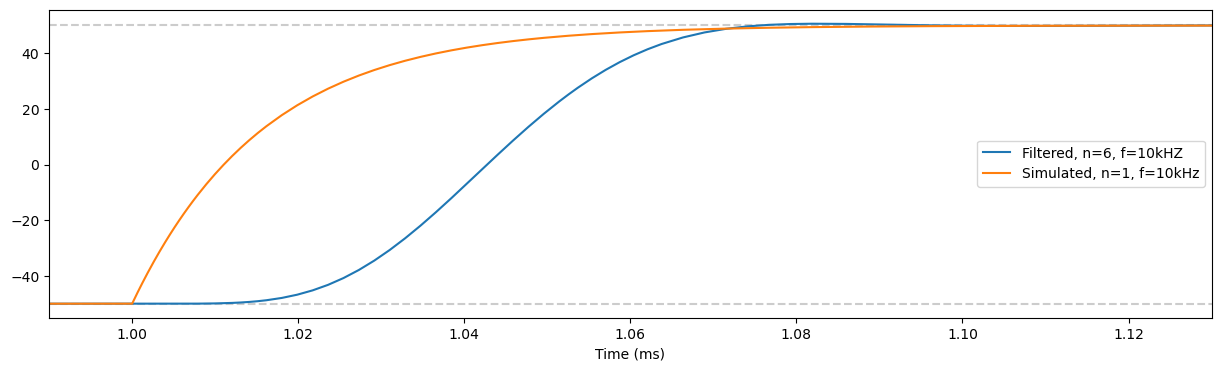

In [26]:
# Update the model to use pacing
# We also re-interpret time as being in ms, making the frequency 10 kHz
m.get('f.u').set_rhs('p')
p = myokit.Protocol()
p.add_step(level=-50, duration=1)
p.add_step(level=50, duration=1)
s = myokit.Simulation(m, p)
s.pre(1)
e = s.run(2)
t, u, y, z = e.time(), e['f.u'], e['f.y6'], e['f.z1']

fig = plt.figure(figsize=(15, 4))
ax = fig.add_subplot()
ax.set_xlabel('Time (ms)')
ax.axhline(-50, color='#ccc', ls='--')
ax.axhline(+50, color='#ccc', ls='--')
ax.plot(t, y, label='Filtered, n=6, f=10kHZ')
ax.plot(t, z, label='Simulated, n=1, f=10kHz')
ax.set_xlim(0.99, 1.13)
ax.legend()
plt.show()

Here we can see the much faster response of the 1-pole filter, and the much smoother response of the 6-pole.
The phase-shift in the 6-pole causes a notable delay in the jump.

The effects are very shortlived though, so we're unlikely to notice this until we sample at a high rate and really zoom in.
At 10kHz, the filters seem unlikely to have a big effect on any currents.